# 6. Улучшение модели и анализ ошибок

В предыдущем разделе были обучены шесть baseline-архитектур (VGG-19, ResNet-50, EfficientNetV2S, DenseNet-201, Swin-V2-Tiny, ViT-B/16) и проведена их сравнительная оценка.

**EfficientNetV2S** показала лучший результат по ключевым метрикам — QWK (0.7092), AUC (0.8605). Данная архитектура выбрана для дальнейшей оптимизации.

Параметры baseline:

| Параметр            | Значение                                                                                                                                                                                                                            |
|---------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Архитектура         | EfficientNetV2S (pretrained ImageNet)                                                                                                                                                                                               |
| Размороженнные слои | `classifier` + `features[-1]` + `features[-2]`                                                                                                                                                                                      |
| Оптимизатор         | Adam                                                                                                                                                                                                                                |
| Шаг обучения        | 1e-3 (классификатор), 1e-4 (последние 2 сверточных слоя)                                                                                                                                                                            |
| Функция потерь      | CrossEntropyLoss                                                                                                                                                                                                                    |
| Batch size          | 32                                                                                                                                                                                                                                  |
| Максимум эпох       | 20                                                                                                                                                                                                                                  |
| Early stopping      | 5 эпох без улучшения                                                                                                                                                                                                                |
| Аугментация         | случайное горизонтальное отражение<br>случайный поворот до 180°<br>случайный сдвиг, масштабирование (±20%) и shear 11.5°<br>случайное изменение яркости, контраста, насыщенности и оттенка<br>размытие по Гауссу с вероятностью 0.5 |

## 6.1 Проведение экспериментов по улучшению модели

Каждый подраздел — отдельный мини-эксперимент. Изменяется ровно один параметр, остальные — фиксированы. Результат каждого эксперимента сравнивается с baseline по QWK и AUC на тестовой выборке. AUC вычисляется отдельно для каждого из трех клинических порогов:

| Порог | Positive (больной) | Negative (здоровый) | Клинический смысл |
|---|---|---|---|
| **Any DR** | классы 1–4 | класс 0 | Есть ли заболевание? |
| **RDR** (Referable DR) | классы 2–4 | классы 0–1 | Нужно ли направить к офтальмологу? |
| **STDR** (Sight-Threatening DR) | классы 3–4 | классы 0–2 | Есть ли угроза потери зрения? |

In [ ]:
import copy
import os
from pathlib import Path

import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.io import read_image
from torchvision.models import (
    efficientnet_v2_s, EfficientNet_V2_S_Weights,
)
from IPython.display import clear_output
from tqdm import tqdm
from tqdm.auto import tqdm as tqdm_auto
from sklearn.metrics import (
    cohen_kappa_score, roc_auc_score,
    roc_curve,
)

In [ ]:
TRAIN_DF_PATH        = 'data/labels/train.csv'
TEST_DF_PATH         = 'data/labels/test.csv'
RAW_IMAGES_DIR       = 'data/raw_images'
IMAGES_DIR           = 'data/processed_images/processed_images'
IMAGES_DIR_384       = 'data/processed_images_384/processed_images_384'
MODELS_BASELINE_DIR  = 'data/models/experiments'
MODELS_DIR           = 'data/models/experiments'
LOSS_FN              = nn.CrossEntropyLoss()
LOSS_FN_REG          = nn.SmoothL1Loss()
MAX_EPOCHS           = 20
MAX_EPOCHS_FINAL     = 30
BATCH_SIZE           = 32
EARLY_STOPPING       = 5
EARLY_STOPPING_FINAL = 10

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

In [ ]:
def find_image(directory, id_code):
    for ext in ('.png', '.jpg', '.jpeg'):
        path = os.path.join(directory, f'{id_code}{ext}')
        if os.path.exists(path):
            return path

    raise FileNotFoundError(f'No image found for {id_code} in {directory}')


class DRDataset(torch.utils.data.Dataset):
    def __init__(self, df, image_dir, transform=None, regression=False):
        self.records = df[['id_code', 'diagnosis']].reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.regression = regression

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        row = self.records.iloc[idx]
        img = read_image(find_image(self.image_dir, row['id_code']))
        if self.transform:
            img = self.transform(img)
        label = float(row['diagnosis']) if self.regression else row['diagnosis']
        return img, label


def make_train_transform(weights):
    aug = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(180),
        transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), scale=(0.8, 1.2), shear=11.5),
        transforms.ColorJitter(brightness=0.08, contrast=0.2, saturation=0.08, hue=0.028),
        transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.5),
    ])

    return transforms.Compose([aug, weights.transforms()])


def plot_stats(train_loss, test_loss, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_title(f'{title} — Loss')
    ax.plot(train_loss, label='Train')
    ax.plot(test_loss,  label='Test')
    ax.legend(); ax.grid()
    plt.tight_layout(); plt.show()


def _train_epoch(model, optimizer, loader, loss_fn, squeeze_output=False):
    model.train()
    total = 0.0

    for x, y in tqdm(loader, desc='Train', leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = loss_fn(out.squeeze(1) if squeeze_output else out, y)
        loss.backward()
        optimizer.step()
        total += loss.item()

    return total / len(loader)


@torch.inference_mode()
def _evaluate(model, loader, loss_fn, squeeze_output=False):
    model.eval()
    total = 0.0

    for x, y in tqdm(loader, desc='Eval', leave=False):
        x, y = x.to(device), y.to(device)
        out = model(x)
        total += loss_fn(out.squeeze(1) if squeeze_output else out, y).item()

    return total / len(loader)


def _fit(
    model,
    optimizer,
    train_loader,
    test_loader,
    max_epochs,
    title,
    loss_fn,
    early_stopping,
    squeeze_output=False
):
    train_losses, test_losses = [], []
    best_loss, best_state, no_improve = float('inf'), None, 0

    for epoch in range(max_epochs):
        tr = _train_epoch(model, optimizer, train_loader, loss_fn, squeeze_output)
        ts = _evaluate(model, test_loader, loss_fn, squeeze_output)
        train_losses.append(tr); test_losses.append(ts)
        clear_output(wait=True)
        plot_stats(train_losses, test_losses, title)

        print(f'Epoch {epoch+1}/{max_epochs} | Train {tr:.4f} | Test {ts:.4f}')

        if ts < best_loss:
            best_loss, best_state, no_improve = ts, copy.deepcopy(model.state_dict()), 0
        else:
            no_improve += 1
            if no_improve >= early_stopping:
                print(f'Early stopping на эпохе {epoch+1}')
                break

    model.load_state_dict(best_state)


def train_model(
    name,
    weights,
    model,
    optimizer,
    loss_fn,
    train_df_path,
    test_df_path,
    images_dir,
    models_dir,
    max_epochs,
    batch_size,
    early_stopping,
    train_transform=None,
    regression=False
):
    fname = name.lower().replace('-', '').replace(' ', '_')
    _tr = train_transform if train_transform is not None else make_train_transform(weights)

    train_loader = DataLoader(
        dataset=DRDataset(
            pd.read_csv(train_df_path),
            images_dir,
            _tr,
            regression=regression
        ),
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )

    test_loader = DataLoader(
        dataset=DRDataset(
            pd.read_csv(test_df_path),
            images_dir,
            weights.transforms(),
            regression=regression
        ),
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    print(f"\n{'='*40}\n{name}\n{'='*40}")

    _fit(
        model=model,
        optimizer=optimizer,
        train_loader=train_loader,
        test_loader=test_loader,
        max_epochs=max_epochs,
        title=name,
        loss_fn=loss_fn,
        early_stopping=early_stopping,
        squeeze_output=regression
    )

    os.makedirs(models_dir, exist_ok=True)
    path = os.path.join(models_dir, f'{fname}.pth')
    torch.save(model.state_dict(), path)

    print(f'Сохранено: {path}')


@torch.inference_mode()
def get_predictions(model, loader, desc='Inference'):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []

    for x, y in tqdm(loader, desc=desc, leave=True):
        logits = model(x.to(device))
        probs  = F.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_preds.append(logits.argmax(dim=1).cpu().numpy())
        all_labels.append(y.numpy())

    probs_out  = np.concatenate(all_probs)
    preds_out  = np.concatenate(all_preds)
    labels_out = np.concatenate(all_labels)

    print(f'  [{desc}] samples processed: {len(preds_out)}')

    return probs_out, preds_out, labels_out


def compute_metrics(y_true, y_pred, y_probs=None, y_scores=None):
    result = {
        'QWK': cohen_kappa_score(y_true, y_pred, weights='quadratic'),
    }

    if y_probs is not None:
        s_any_dr = 1 - y_probs[:, 0]
        s_rdr    = y_probs[:, 2:].sum(axis=1)
        s_stdr   = y_probs[:, 3:].sum(axis=1)
    elif y_scores is not None:
        s_any_dr = s_rdr = s_stdr = y_scores
    else:
        return result

    result['AUC Any DR'] = roc_auc_score((y_true >= 1).astype(int), s_any_dr)
    result['AUC RDR']    = roc_auc_score((y_true >= 2).astype(int), s_rdr)
    result['AUC STDR']   = roc_auc_score((y_true >= 3).astype(int), s_stdr)

    return result


def show_metrics_table(rows, metric_cols, title):
    df = pd.DataFrame(rows).set_index('Model')

    fig, ax = plt.subplots(figsize=(11, 1.8))
    ax.axis('off')
    tbl = ax.table(
        cellText=[[f'{v:.4f}' for v in row] for row in df.values],
        rowLabels=df.index, colLabels=metric_cols,
        cellLoc='center', loc='center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.5)
    for j, col in enumerate(metric_cols):
        best = df[col].max()
        for i, val in enumerate(df[col]):
            if val == best:
                tbl[i + 1, j].set_facecolor('#d4edda')
    plt.title(title, fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()

    print('\nДельта:')
    for k in metric_cols:
        d = df[k].iloc[-1] - df[k].iloc[0]
        print(f'  {k}: {d:+.4f}')

### 6.1.1 Регрессионный лосс (SmoothL1)

**Гипотеза:** `CrossEntropyLoss` не учитывает ординальность классов — ошибка между дальними классами штрафуется так же, как между соседними. `SmoothL1Loss` трактует задачу как регрессию: модель предсказывает вещественное число, которое затем округляется до целого и обрезается в диапазон [0, 4]. Это естественно согласуется с QWK, который тоже штрафует дальние ошибки сильнее.

In [ ]:
@torch.inference_mode()
def get_predictions_reg(model, loader, desc='Inference'):
    model.eval()
    all_scores, all_preds, all_labels = [], [], []

    for x, y in tqdm(loader, desc=desc, leave=True):
        raw = model(x.to(device)).squeeze(1).cpu()
        all_scores.append(raw.numpy())
        all_preds.append(raw.round().clamp(0, 4).long().numpy())
        all_labels.append(y.numpy().astype(int))

    scores = np.concatenate(all_scores)
    preds  = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)

    print(f'  [{desc}] samples: {len(preds)}')

    return scores, preds, labels

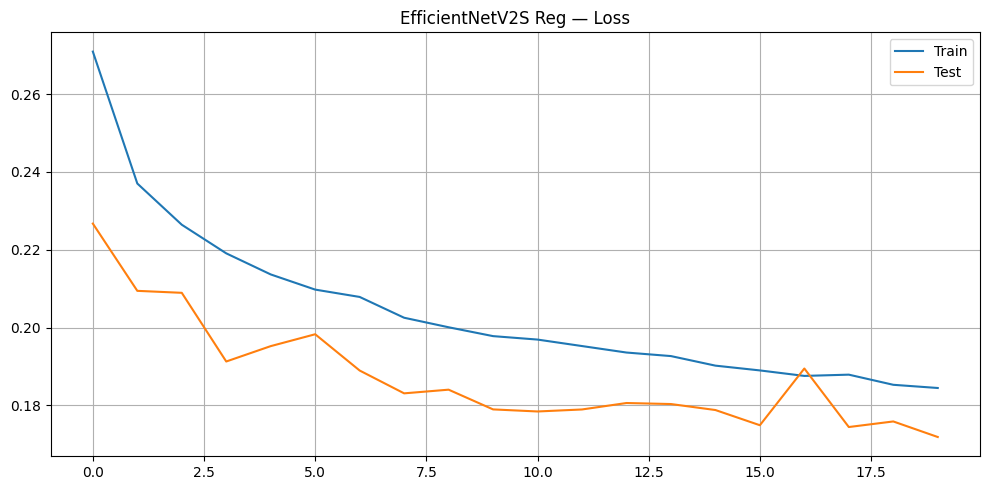

Epoch 20/20 | Train 0.1845 | Test 0.1719
Saved: /content/efficientnetv2s_reg.pth


In [ ]:
eff_weights = EfficientNet_V2_S_Weights.DEFAULT
model_eff_reg = efficientnet_v2_s(weights=eff_weights)

for p in model_eff_reg.parameters():
    p.requires_grad = False

model_eff_reg.classifier[1] = nn.Linear(1280, 1)
model_eff_reg.classifier.requires_grad_(True)
model_eff_reg.features[-1].requires_grad_(True)
model_eff_reg.features[-2].requires_grad_(True)

model_eff_reg = model_eff_reg.to(device)

optimizer_eff_reg = Adam([
    {'params': model_eff_reg.classifier.parameters(), 'lr': 1e-3},
    {'params': list(model_eff_reg.features[-1].parameters()) +
               list(model_eff_reg.features[-2].parameters()), 'lr': 1e-4},
])

train_model(
    name='EfficientNetV2S Reg',
    weights=eff_weights,
    model=model_eff_reg,
    optimizer=optimizer_eff_reg,
    loss_fn=LOSS_FN_REG,
    train_df_path=TRAIN_DF_PATH,
    test_df_path=TEST_DF_PATH,
    images_dir=IMAGES_DIR,
    models_dir=MODELS_DIR,
    max_epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    early_stopping=EARLY_STOPPING,
    regression=True,
)

EfficientNetV2S Reg: 100%|██████████| 288/288 [03:12<00:00,  1.49it/s]


  [EfficientNetV2S Reg] samples: 18403


EfficientNetV2S Baseline: 100%|██████████| 288/288 [03:12<00:00,  1.50it/s]


  [EfficientNetV2S Baseline] samples processed: 18403


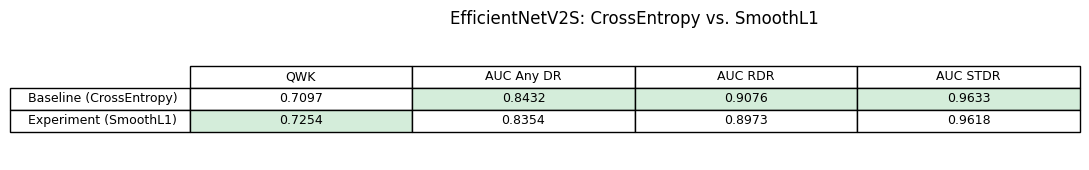


Дельта:
  QWK: +0.0157
  AUC Any DR: -0.0078
  AUC RDR: -0.0103
  AUC STDR: -0.0015


In [ ]:
eff_weights = EfficientNet_V2_S_Weights.DEFAULT

model_eff_reg = efficientnet_v2_s(weights=None)
model_eff_reg.classifier[1] = nn.Linear(1280, 1)
model_eff_reg.load_state_dict(torch.load(
    os.path.join(MODELS_DIR, 'efficientnetv2s_reg.pth'), map_location=device))
model_eff_reg = model_eff_reg.to(device)

scores_reg, preds_reg, labels_reg = get_predictions_reg(model_eff_reg,
    DataLoader(DRDataset(pd.read_csv(TEST_DF_PATH), IMAGES_DIR, eff_weights.transforms()),
               batch_size=64, shuffle=False, num_workers=4, pin_memory=True),
    desc='EfficientNetV2S Reg')
metrics_reg = compute_metrics(labels_reg, preds_reg)
metrics_reg['AUC Any DR'] = roc_auc_score((labels_reg >= 1).astype(int), scores_reg)
metrics_reg['AUC RDR']    = roc_auc_score((labels_reg >= 2).astype(int), scores_reg)
metrics_reg['AUC STDR']   = roc_auc_score((labels_reg >= 3).astype(int), scores_reg)

model_eff_base = efficientnet_v2_s(weights=None)
model_eff_base.classifier[1] = nn.Linear(1280, 5)
model_eff_base.load_state_dict(torch.load(
    os.path.join(MODELS_BASELINE_DIR, 'efficientnetv2s.pth'), map_location=device))
model_eff_base = model_eff_base.to(device)

probs_base, preds_base, labels_base = get_predictions(model_eff_base,
    DataLoader(DRDataset(pd.read_csv(TEST_DF_PATH), IMAGES_DIR, eff_weights.transforms()),
               batch_size=64, shuffle=False, num_workers=4, pin_memory=True),
    desc='EfficientNetV2S Baseline')
metrics_base_621 = compute_metrics(labels_base, preds_base, probs_base)
metrics_base_621['AUC Any DR'] = roc_auc_score((labels_base >= 1).astype(int), 1 - probs_base[:, 0])
metrics_base_621['AUC RDR']    = roc_auc_score((labels_base >= 2).astype(int), probs_base[:, 2:].sum(axis=1))
metrics_base_621['AUC STDR']   = roc_auc_score((labels_base >= 3).astype(int), probs_base[:, 3:].sum(axis=1))

metric_cols = ['QWK', 'AUC Any DR', 'AUC RDR', 'AUC STDR']
show_metrics_table(
    rows=[
        {'Model': 'Baseline (CrossEntropy)',      **{k: metrics_base_621[k] for k in metric_cols}},
        {'Model': 'Experiment (SmoothL1)', **{k: metrics_reg[k]      for k in metric_cols}},
    ],
    metric_cols=metric_cols,
    title='EfficientNetV2S: CrossEntropy vs. SmoothL1',
)

**Вывод:** Гипотеза подтвердилась. SmoothL1Loss увеличил QWK на +0.0157. AUC незначительно снизился по всем порогам (Any DR −0.0078, RDR −0.0103, STDR −0.0015). В рамках данного проекта QWK в приоритете: в контексте медицинского применения важно не допускать грубых ошибок классификации. Оптимизация включена в финальную конфигурацию.

---

### 6.1.2 Более агрессивная аугментация

**Гипотеза:** Текущие аугментации консервативны: `brightness=0.08`, `saturation=0.08`, нет вертикального флипа. Более агрессивная аугментация позволит модели выучить инвариантности, реально присутствующие в данных: фундус-снимки симметричны по обеим осям, яркость и насыщенность варьируются между клиниками, качество фокуса непостоянно.

**Изменения vs. baseline:**
- `RandomVerticalFlip` (добавлено)
- `brightness 0.08 → 0.2`
- `saturation 0.08 → 0.2`
- `RandomAdjustSharpness(p=0.3)` (добавлено)

In [ ]:
def make_train_transform_v2(weights):
    aug = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(180),
        transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), scale=(0.8, 1.2), shear=11.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.028),
        transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.5),
        transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    ])
    return transforms.Compose([aug, weights.transforms()])


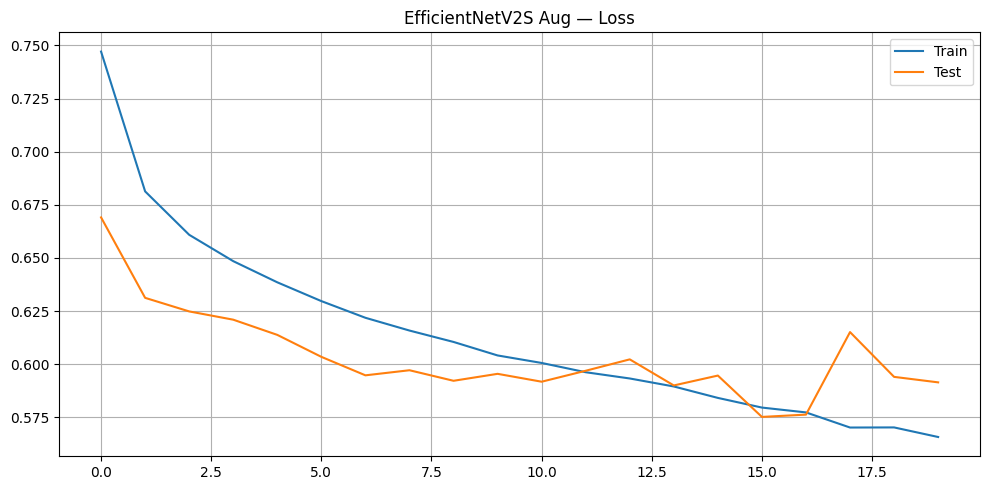

Epoch 20/20 | Train 0.5658 | Test 0.5915
Сохранено: /content/efficientnetv2s_aug.pth


In [ ]:
eff_weights = EfficientNet_V2_S_Weights.DEFAULT
model_eff_aug = efficientnet_v2_s(weights=eff_weights)
for p in model_eff_aug.parameters():
    p.requires_grad = False
model_eff_aug.classifier[1] = nn.Linear(1280, 5)
model_eff_aug.classifier.requires_grad_(True)
model_eff_aug.features[-1].requires_grad_(True)
model_eff_aug.features[-2].requires_grad_(True)
model_eff_aug = model_eff_aug.to(device)

optimizer_eff_aug = Adam([
    {'params': model_eff_aug.classifier.parameters(), 'lr': 1e-3},
    {'params': list(model_eff_aug.features[-1].parameters()) +
               list(model_eff_aug.features[-2].parameters()), 'lr': 1e-4},
])

train_model(
    name='EfficientNetV2S Aug',
    weights=eff_weights,
    model=model_eff_aug,
    optimizer=optimizer_eff_aug,
    loss_fn=LOSS_FN,
    train_df_path=TRAIN_DF_PATH,
    test_df_path=TEST_DF_PATH,
    images_dir=IMAGES_DIR,
    models_dir=MODELS_DIR,
    max_epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    early_stopping=EARLY_STOPPING,
    train_transform=make_train_transform_v2(eff_weights),
)


EfficientNetV2S Aug: 100%|██████████| 288/288 [03:13<00:00,  1.49it/s]


  [EfficientNetV2S Aug] samples processed: 18403


EfficientNetV2S Baseline: 100%|██████████| 288/288 [03:12<00:00,  1.49it/s]


  [EfficientNetV2S Baseline] samples processed: 18403


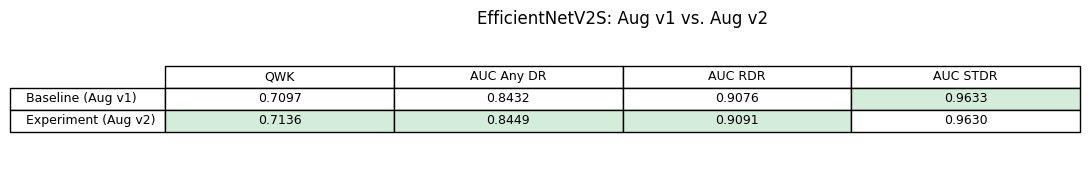


Дельта:
  QWK: +0.0040
  AUC Any DR: +0.0017
  AUC RDR: +0.0015
  AUC STDR: -0.0003


In [ ]:
eff_weights = EfficientNet_V2_S_Weights.DEFAULT

model_eff_aug = efficientnet_v2_s(weights=None)
model_eff_aug.classifier[1] = nn.Linear(1280, 5)
model_eff_aug.load_state_dict(torch.load(
    os.path.join(MODELS_DIR, 'efficientnetv2s_aug.pth'), map_location=device))
model_eff_aug = model_eff_aug.to(device)

probs_aug, preds_aug, labels_aug = get_predictions(model_eff_aug,
    DataLoader(DRDataset(pd.read_csv(TEST_DF_PATH), IMAGES_DIR, eff_weights.transforms()),
               batch_size=64, shuffle=False, num_workers=4, pin_memory=True),
    desc='EfficientNetV2S Aug')
metrics_eff_aug = compute_metrics(labels_aug, preds_aug, y_probs=probs_aug)

model_eff_base = efficientnet_v2_s(weights=None)
model_eff_base.classifier[1] = nn.Linear(1280, 5)
model_eff_base.load_state_dict(torch.load(
    os.path.join(MODELS_BASELINE_DIR, 'efficientnetv2s.pth'), map_location=device))
model_eff_base = model_eff_base.to(device)

probs_base, preds_base, labels_base = get_predictions(model_eff_base,
    DataLoader(DRDataset(pd.read_csv(TEST_DF_PATH), IMAGES_DIR, eff_weights.transforms()),
               batch_size=64, shuffle=False, num_workers=4, pin_memory=True),
    desc='EfficientNetV2S Baseline')
metrics_eff_base = compute_metrics(labels_base, preds_base, y_probs=probs_base)

metric_cols = ['QWK', 'AUC Any DR', 'AUC RDR', 'AUC STDR']
show_metrics_table(
    rows=[
        {'Model': 'Baseline (Aug v1)', **{k: metrics_eff_base[k] for k in metric_cols}},
        {'Model': 'Experiment (Aug v2)',  **{k: metrics_eff_aug[k]  for k in metric_cols}},
    ],
    metric_cols=metric_cols,
    title='EfficientNetV2S: Aug v1 vs. Aug v2',
)

**Вывод:** Результат неоднозначный: QWK +0.0040, AUC Any DR +0.0017, AUC RDR +0.0015, AUC STDR −0.0003. Небольшой прирост может быть шумом. Тем не менее данная оптимизация включена в финальную конфигурацию.

---

### 6.1.3 Увеличение разрешения снимков до 384×384

**Гипотеза:** При предобработке снимков разрешение было уменьшено до 224×224. При таком разрешении ранние признаки ДР (микроаневризмы, мягкий экссудат) могут теряться и не распознаваться моделью.

In [ ]:
path_map_raw = {}
for p in Path(RAW_IMAGES_DIR).rglob('*'):
    if p.suffix.lower() in ('.png', '.jpg', '.jpeg') and p.stem not in path_map_raw:
        path_map_raw[p.stem] = str(p)

print(f'Найдено сырых снимков: {len(path_map_raw)}')

In [4]:
def preprocess(path, desired_size=384):
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f'Cannot read image: {path}')
    img = cv2.copyMakeBorder(img, 10, 10, 10, 10, cv2.BORDER_CONSTANT, value=[0, 0, 0])
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
    img = img[y:y+h, x:x+w]
    h, w = img.shape[:2]
    side = max(h, w)
    padded = np.zeros((side, side, 3), dtype=np.uint8)
    padded[(side-h)//2:(side-h)//2+h, (side-w)//2:(side-w)//2+w] = img
    return cv2.resize(padded, (desired_size, desired_size), interpolation=cv2.INTER_LANCZOS4)


os.makedirs(IMAGES_DIR_384, exist_ok=True)

all_ids = set(pd.read_csv(TRAIN_DF_PATH)['id_code']) | set(pd.read_csv(TEST_DF_PATH)['id_code'])
missing = []

for id_code in tqdm_auto(all_ids, desc='Preprocessing 384px'):
    out_path = os.path.join(IMAGES_DIR_384, f'{id_code}.png')
    if os.path.exists(out_path):
        continue
    if id_code not in path_map_raw:
        missing.append(id_code)
        continue
    img = preprocess(path_map_raw[id_code], desired_size=384)
    if img is not None:
        cv2.imwrite(out_path, img)

processed = list(Path(IMAGES_DIR_384).glob('*.png'))
print(f'Снимков в папке:    {len(processed)}')

Preprocessing 384px:   0%|          | 0/91953 [00:00<?, ?it/s]

Снимков в папке:    91953


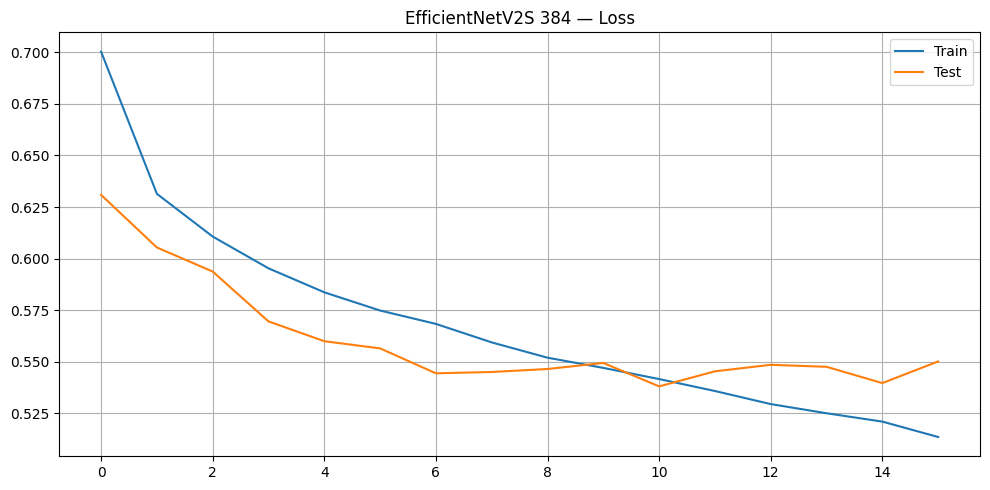

Epoch 16/20 | Train 0.5136 | Test 0.5502
Early stopping на эпохе 16
Сохранено: /content/efficientnetv2s_384.pth


In [ ]:
eff_weights = EfficientNet_V2_S_Weights.DEFAULT
model_eff_384 = efficientnet_v2_s(weights=eff_weights)
for p in model_eff_384.parameters():
    p.requires_grad = False
model_eff_384.classifier[1] = nn.Linear(1280, 5)
model_eff_384.classifier.requires_grad_(True)
model_eff_384.features[-1].requires_grad_(True)
model_eff_384.features[-2].requires_grad_(True)
model_eff_384 = model_eff_384.to(device)

optimizer_eff_384 = Adam([
    {'params': model_eff_384.classifier.parameters(), 'lr': 1e-3},
    {'params': list(model_eff_384.features[-1].parameters()) +
               list(model_eff_384.features[-2].parameters()), 'lr': 1e-4},
])

train_model(
    name='EfficientNetV2S 384',
    weights=eff_weights,
    model=model_eff_384,
    optimizer=optimizer_eff_384,
    loss_fn=LOSS_FN,
    train_df_path=TRAIN_DF_PATH,
    test_df_path=TEST_DF_PATH,
    images_dir=IMAGES_DIR_384,
    models_dir=MODELS_DIR,
    max_epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    early_stopping=EARLY_STOPPING,
)

EfficientNetV2S 384: 100%|██████████| 288/288 [03:12<00:00,  1.50it/s]


  [EfficientNetV2S 384] samples processed: 18403


EfficientNetV2S 224 (baseline): 100%|██████████| 288/288 [03:12<00:00,  1.50it/s]


  [EfficientNetV2S 224 (baseline)] samples processed: 18403


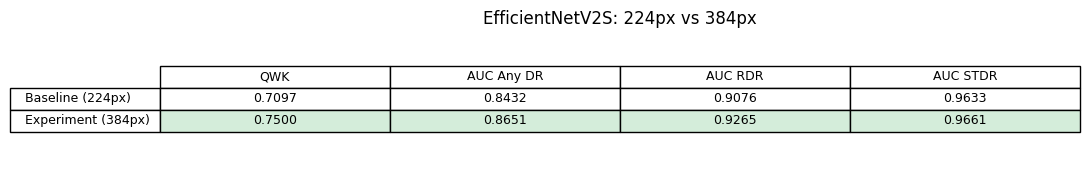


Дельта:
  QWK: +0.0403
  AUC Any DR: +0.0219
  AUC RDR: +0.0190
  AUC STDR: +0.0028


In [ ]:
eff_weights = EfficientNet_V2_S_Weights.DEFAULT

model_eff_384 = efficientnet_v2_s(weights=None)
model_eff_384.classifier[1] = nn.Linear(1280, 5)
model_eff_384.load_state_dict(torch.load(
    os.path.join(MODELS_DIR, 'efficientnetv2s_384.pth'), map_location=device))
model_eff_384 = model_eff_384.to(device)

probs_384, preds_384, labels_384 = get_predictions(model_eff_384,
    DataLoader(DRDataset(pd.read_csv(TEST_DF_PATH), IMAGES_DIR_384, eff_weights.transforms()),
               batch_size=64, shuffle=False, num_workers=4, pin_memory=True),
    desc='EfficientNetV2S 384')
metrics_384 = compute_metrics(labels_384, preds_384, y_probs=probs_384)

model_eff_base = efficientnet_v2_s(weights=None)
model_eff_base.classifier[1] = nn.Linear(1280, 5)
model_eff_base.load_state_dict(torch.load(
    os.path.join(MODELS_BASELINE_DIR, 'efficientnetv2s.pth'), map_location=device))
model_eff_base = model_eff_base.to(device)

probs_base, preds_base, labels_base = get_predictions(model_eff_base,
    DataLoader(DRDataset(pd.read_csv(TEST_DF_PATH), IMAGES_DIR, eff_weights.transforms()),
               batch_size=64, shuffle=False, num_workers=4, pin_memory=True),
    desc='EfficientNetV2S 224 (baseline)')
metrics_base = compute_metrics(labels_base, preds_base, y_probs=probs_base)

metric_cols = ['QWK', 'AUC Any DR', 'AUC RDR', 'AUC STDR']
show_metrics_table(
    rows=[
        {'Model': 'Baseline (224px)', **{k: metrics_base[k] for k in metric_cols}},
        {'Model': 'Experiment (384px)',            **{k: metrics_384[k]  for k in metric_cols}},
    ],
    metric_cols=metric_cols,
    title='EfficientNetV2S: 224px vs 384px',
)

**Вывод:** Гипотеза подтвердилась. QWK вырос на +0.0403, AUC Any DR +0.0219, AUC RDR +0.0190, AUC STDR +0.0028. Разрешение оказалось главным фактором прироста метрик из трех проверенных. Оптимизация включена в финальную конфигурацию.

---

## 6.2 Обучение модели с выбранными оптимизациями

In [ ]:
eff_weights = EfficientNet_V2_S_Weights.DEFAULT

model_final = efficientnet_v2_s(weights=eff_weights)
for p in model_final.parameters():
    p.requires_grad = False
model_final.classifier[1] = nn.Linear(1280, 1)
model_final.classifier.requires_grad_(True)
model_final.features[-1].requires_grad_(True)
model_final.features[-2].requires_grad_(True)
model_final = model_final.to(device)

optimizer_final = Adam([
    {'params': model_final.classifier.parameters(),                 'lr': 1e-3},
    {'params': list(model_final.features[-1].parameters()) +
               list(model_final.features[-2].parameters()),         'lr': 1e-4},
])

train_model(
    name='EfficientNetV2S Final',
    weights=eff_weights,
    model=model_final,
    optimizer=optimizer_final,
    loss_fn=nn.SmoothL1Loss(),
    train_df_path=TRAIN_DF_PATH,
    test_df_path=TEST_DF_PATH,
    images_dir=IMAGES_DIR_384,
    models_dir=MODELS_DIR,
    max_epochs=MAX_EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    early_stopping=EARLY_STOPPING_FINAL,
    train_transform=make_train_transform_v2(eff_weights),
    regression=True,
)

In [ ]:
eff_weights = EfficientNet_V2_S_Weights.DEFAULT
model_final = efficientnet_v2_s(weights=None)
model_final.classifier[1] = nn.Linear(1280, 1)
model_final.load_state_dict(torch.load(
    os.path.join(MODELS_DIR, 'efficientnetv2s_final.pth'), map_location=device))
model_final = model_final.to(device)

test_loader_final = DataLoader(
    DRDataset(pd.read_csv(TEST_DF_PATH), IMAGES_DIR_384,
              eff_weights.transforms(), regression=True),
    batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

scores_final, preds_final, labels_final = get_predictions_reg(
    model_final, test_loader_final, desc='Final Model')
metrics_final = compute_metrics(labels_final, preds_final, y_scores=scores_final)

model_eff_base = efficientnet_v2_s(weights=None)
model_eff_base.classifier[1] = nn.Linear(1280, 5)
model_eff_base.load_state_dict(torch.load(
    os.path.join(MODELS_BASELINE_DIR, 'efficientnetv2s.pth'), map_location=device))
model_eff_base = model_eff_base.to(device)

probs_base, preds_base, labels_base = get_predictions(model_eff_base,
    DataLoader(DRDataset(pd.read_csv(TEST_DF_PATH), IMAGES_DIR, eff_weights.transforms()),
               batch_size=64, shuffle=False, num_workers=4, pin_memory=True),
    desc='Baseline')
metrics_base = compute_metrics(labels_base, preds_base, y_probs=probs_base)

metric_cols = ['QWK', 'AUC Any DR', 'AUC RDR', 'AUC STDR']
show_metrics_table(
    rows=[
        {'Model': 'Baseline',    **{k: metrics_base[k]  for k in metric_cols}},
        {'Model': 'Optimized', **{k: metrics_final[k] for k in metric_cols}},
    ],
    metric_cols=metric_cols,
    title='Baseline vs. Optimized',
)

---

## 6.3 Подробный анализ метрик и ошибок модели после оптимизации

В данный момент финальная модель обучается. Раздел будет заполнен в ближайшее время

---

## 6.4 Бэклог дальнейшей оптимизации

- **Более агрессивная фильтрация по яркости и резкости**. Текущие пороги (`brightness < 20`, `brightness > 210`, `blur < 30`) отсекают только явный брак. Ужесточение порогов позволит убрать снимки низкого качества, которые затрудняют обучение и могут ухудшать метрики.
- **Undersampling доминирующего класса**. Класс No DR составляет ~73% выборки. Уменьшение его доли до уровня остальных классов может помочь модели лучше распознавать редкие классы.
- **Более глубокое размораживание backbone**. Сейчас размораживается только последний блок каждой модели. Постепенное размораживание дополнительных слоев может позволить модели адаптировать больше признаков под специфику снимков глазного дна.
- **Подбор гиперпараметров**. learning rate, batch size и scheduler выставлены вручную без оптимизации. Автоматический подбор — один из наиболее очевидных резервов роста качества.
- **Увеличение входного разрешения до 512×512**. Эксперимент в разделе 6.1.3 показал, что разрешение — ключевой фактор качества: переход с 224px на 384px дал наибольший прирост среди всех экспериментов (+0.0403 QWK). Дальнейшее увеличение до 512×512 может дать дополнительный прирост за счет еще более мелких деталей снимка.